In [27]:
print('hi')

hi


In [28]:
import numpy as np
import networkx as nx
import pandas as pd
import random
from collections import defaultdict
import matplotlib.pyplot as plt

In [29]:
def generate_SBM(seed, num_blocks, block_size, p_in, p_out):
    np.random.seed(seed)
    random.seed(seed)

    n = num_blocks * block_size

    labels = np.repeat(np.arange(num_blocks), block_size)

    p_in = 0.8
    p_out = 0.2

    P = np.full((num_blocks, num_blocks), p_out)
    np.fill_diagonal(P, p_in)

    A = np.zeros((n, n))

    for i in range(n):
        for j in range(i+1, n):
            pi = P[labels[i], labels[j]]
            if np.random.rand() < pi:
                A[i, j] = 1
                A[j, i] = 1

    G = nx.from_numpy_array(A)

    df = pd.DataFrame({
        "node_id": np.arange(n),
        "block": labels
    })

    df["degree"] = dict(G.degree()).values()

    return G, labels, df


G, labels, df = generate_SBM(seed=42, num_blocks=3, block_size=50, p_in=0.8, p_out=0.2)

In [30]:
opinions_all = [1, 2, 3, 4]

# 1. assign a dominant opinion to each block
block_dominant = {
    b: np.random.choice(opinions_all)
    for b in range(num_blocks)
}

opinions = []

correlation = 0.8

for i in range(n):
    b = df.loc[i, "block"]
    dominant = block_dominant[b]

    # build probability vector
    probs = np.full(4, (1 - correlation) / 3)  # 3 non-dominant opinions
    probs[dominant - 1] = correlation    # index shift (opinions are 1–4)

    # sample
    opinions.append(np.random.choice(opinions_all, p=probs))

df["opinion"] = opinions

In [31]:
print(df)

     node_id  block  degree  opinion
0          0      0      64        4
1          1      0      59        4
2          2      0      68        3
3          3      0      52        4
4          4      0      67        3
..       ...    ...     ...      ...
145      145      2      68        1
146      146      2      59        3
147      147      2      71        1
148      148      2      54        3
149      149      2      67        3

[150 rows x 4 columns]


In [32]:
# perform rds on the graph given
def rds_with_tracking(G, seeds, sample_size=50, max_recruits=2):
    import random
    
    sampled = set(seeds)
    queue = [(s, 0) for s in seeds]  # (node, wave)
    
    records = []
    
    # initialize seeds
    for s in seeds:
        records.append({
            "node_id": s,
            "recruiter": None,
            "wave": 0
        })
    
    referrer_to_recruits = defaultdict(list)
    
    while queue and len(sampled) < sample_size:
        node, wave = queue.pop(0)
        
        neighbors = list(G.neighbors(node))
        random.shuffle(neighbors)
        
        recruits = 0
        
        for nb in neighbors:
            if nb not in sampled:
                sampled.add(nb)
                
                records.append({
                    "node_id": nb,
                    "recruiter": node,
                    "wave": wave + 1
                })

                referrer_to_recruits[node].append(nb)
                
                queue.append((nb, wave + 1))
                
                recruits += 1
                if recruits >= max_recruits or len(sampled) >= sample_size:
                    break
    
    return pd.DataFrame(records), referrer_to_recruits

seeds = random.sample(range(n), 5)

rds_df, referrer_to_recruits = rds_with_tracking(G, seeds, sample_size=30, max_recruits=2)

rds_df = rds_df.merge(df[["node_id", "opinion", "degree", "block"]], on="node_id", how="left")
print(rds_df)

    node_id  recruiter  wave  opinion  degree  block
0        28        NaN     0        1      56      0
1         6        NaN     0        4      61      0
2        70        NaN     0        4      61      1
3        62        NaN     0        1      60      1
4        57        NaN     0        1      61      1
5        46       28.0     1        4      53      0
6        25       28.0     1        4      60      0
7        12        6.0     1        4      58      0
8         0        6.0     1        4      64      0
9         9       70.0     1        4      58      0
10       80       70.0     1        1      71      1
11      148       62.0     1        3      54      2
12      136       62.0     1        1      64      2
13       87       57.0     1        1      54      1
14       15       57.0     1        4      59      0
15       31       46.0     2        2      59      0
16       32       46.0     2        4      66      0
17       33       25.0     2        4      61 

In [33]:
print(referrer_to_recruits)

defaultdict(<class 'list'>, {28: [46, 25], 6: [12, 0], 70: [9, 80], 62: [148, 136], 57: [87, 15], 46: [31, 32], 25: [33, 14], 12: [42, 71], 0: [45, 20], 9: [116, 118], 80: [88, 65], 148: [130, 145], 136: [146]})


In [34]:
def vh_estimator(rds_df):
    weights = 1 / rds_df["degree"]
    
    weighted_counts = (
        rds_df
        .assign(weight=weights)
        .groupby("opinion")["weight"]
        .sum()
    )

    return (weighted_counts / weighted_counts.sum()).sort_index()

def get_distribution(series):
    return series.value_counts(normalize=True).sort_index()


def total_variation(p, q):
    idx = sorted(set(p.index).union(q.index))
    p = p.reindex(idx, fill_value=0)
    q = q.reindex(idx, fill_value=0)
    return 0.5 * np.abs(p - q).sum()


def kl_divergence(p_true, p_est, eps=1e-12):
    """KL(true || est): information lost when est is used to encode true.
    Small eps avoids -inf when an opinion is missing from the estimator."""
    idx = sorted(set(p_true.index).union(p_est.index))
    p = p_true.reindex(idx, fill_value=0).values.astype(float) + eps
    q = p_est.reindex(idx, fill_value=0).values.astype(float) + eps
    p = p / p.sum()
    q = q / q.sum()
    return float(np.sum(p * np.log(p / q)))

In [35]:
recruiter_map = {}

for r, recruits in referrer_to_recruits.items():
    for u in recruits:
        recruiter_map[u] = r

In [36]:
def vh_with_homophily_adjustment(rds_df, recruiter_map, alpha=0.5):
    weights = []
    
    for _, row in rds_df.iterrows():
        node = row["node_id"]
        base_weight = 1 / row["degree"]
        
        recruiter = recruiter_map.get(node, None)
        
        if recruiter is None:
            weights.append(base_weight)  # seed
            continue
        
        # compare blocks
        if df.loc[node, "block"] == df.loc[recruiter, "block"]:
            weights.append(alpha * base_weight)
        else:
            weights.append(base_weight)
    
    rds_df = rds_df.copy()
    rds_df["weight"] = weights
    
    weighted_counts = (
        rds_df
        .groupby("opinion")["weight"]
        .sum()
    )
    
    return (weighted_counts / weighted_counts.sum()).sort_index()

def compute_alpha(correlation, SBM_p):
    k = 1 / (1 - SBM_p)
    return 1 / (1 + (k - 1) * correlation)

sample_dist = get_distribution(rds_df["opinion"])
vh_dist = vh_estimator(rds_df)
found_alpha = compute_alpha(correlation=correlation, SBM_p=p_in)  # Example values
adj_dist = vh_with_homophily_adjustment(rds_df, recruiter_map, alpha=found_alpha)
pop_dist = get_distribution(df["opinion"])

print("Sample distribution:\n", sample_dist, "\n")
print("Adjusted VH estimate:\n", adj_dist, "\n")
print("True population distribution:\n", pop_dist, "\n")

print("KL (sample vs population):", kl_divergence(sample_dist, pop_dist))
print("KL (VH vs population):", kl_divergence(vh_dist, pop_dist))
print("KL (Adjusted vs population):", kl_divergence(adj_dist, pop_dist))

Sample distribution:
 opinion
1    0.333333
2    0.066667
3    0.133333
4    0.466667
Name: proportion, dtype: float64 

Adjusted VH estimate:
 opinion
1    0.371873
2    0.027878
3    0.210351
4    0.389898
Name: weight, dtype: float64 

True population distribution:
 opinion
1    0.346667
2    0.060000
3    0.300000
4    0.293333
Name: proportion, dtype: float64 

KL (sample vs population): 0.10250238495763124
KL (VH vs population): 0.09871274062678026
KL (Adjusted vs population): 0.04101230375963914


Optimal alpha: 0.17 with KL divergence 0.0395


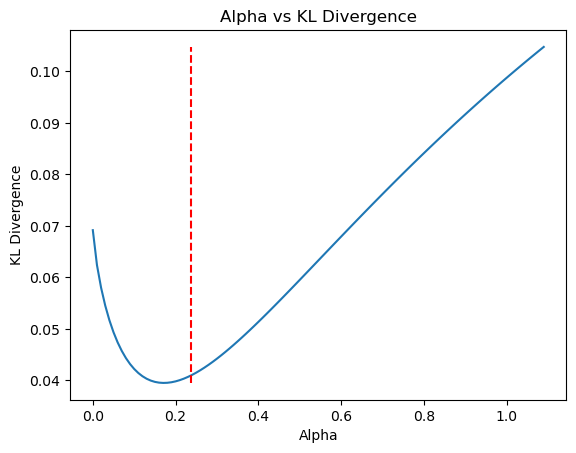

In [37]:
alphas = np.arange(0, 1.1, 0.01)
kl_vals = []

for alpha in alphas:
    adj_dist = vh_with_homophily_adjustment(rds_df, recruiter_map, alpha=alpha)
    kl = kl_divergence(adj_dist, pop_dist)
    kl_vals.append(kl)

true_best_alpha = np.argmin(kl_vals)
print(f"Optimal alpha: {alphas[true_best_alpha]:.2f} with KL divergence {kl_vals[true_best_alpha]:.4f}")

plt.plot(alphas, kl_vals)
plt.xlabel("Alpha")
plt.ylabel("KL Divergence")
plt.title("Alpha vs KL Divergence")
plt.vlines(x=found_alpha, ymin=min(kl_vals), ymax=max(kl_vals), colors='r', linestyles='dashed', label=f'Optimal alpha={alpha:.2f}')
plt.show()

In [38]:
# TODO make a distribution of found_alpha versus true optimal alpha across multiple runs